# Question 2 - Part 2: Attack Success Metrics and Similarity Diagnostics

This notebook evaluates two AASIST checkpoints on a 100-sample set (50 real + 50 synthetic), and reports:
- EER
- Confusion matrix
- F1-score
- Attack Success Rate (synthetic predicted as bonafide)

It also provides diagnostics via similarity score distributions for:
- real-real pairs
- real-synthetic pairs

In [2]:
import math
import random
from dataclasses import dataclass, field
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, f1_score, roc_curve

sns.set_style('whitegrid')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


/DATA/teaching/conda_cache/envs/don/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
# Paths and evaluation settings
ROOT = Path('/DATA/Trashaimpms/ekansh')

MODEL_PATHS = {
    'ModelA': ROOT / 'ModelA_LA_bestnew.pt',
    'ModelB': ROOT / 'ModelB_PA_bestnew.pt',
}
THRESHOLDS = {
    'ModelA': 0.420,
    'ModelB': 0.118,
}

REAL_DIR = ROOT / 'DL1'
SYN_DIRS = [
    ROOT / 'generated' / 'dl1_xtts_ft' / 'speaker1',
    ROOT / 'generated' / 'dl1_xtts_ft' / 'speaker2',
]

real_files = sorted(REAL_DIR.glob('*.wav'), key=lambda p: int(p.stem))
syn_files = []
for d in SYN_DIRS:
    syn_files.extend(sorted(d.glob('*.wav')))

# Target is 50 real + 50 synthetic
real_files = real_files[:50]
syn_files = syn_files[:50]

assert len(real_files) == 50, f'Expected 50 real files, got {len(real_files)}'
assert len(syn_files) == 50, f'Expected 50 synthetic files, got {len(syn_files)}'

eval_rows = []
for p in real_files:
    eval_rows.append({'path': p, 'label': 0, 'set': 'real'})
for p in syn_files:
    eval_rows.append({'path': p, 'label': 1, 'set': 'synthetic'})

eval_df = pd.DataFrame(eval_rows)
print('Evaluation samples:', len(eval_df))
print(eval_df['set'].value_counts())

Evaluation samples: 100
set
real         50
synthetic    50
Name: count, dtype: int64


In [4]:
# AASIST architecture (matching your notebook)
@dataclass
class Config:
    sample_rate: int = 16000
    sinc_kernel: int = 1024
    nb_samp: int = 64600
    filts: list = field(default_factory=lambda: [70, [70, 32], [32, 32], [32, 64], [64, 64]])
    nb_fc_node: int = 64
    gat_dims: list = field(default_factory=lambda: [64, 32])
    temperatures: list = field(default_factory=lambda: [2.0, 2.0, 100.0, 100.0])

CFG = Config()

class SincConv(nn.Module):
    @staticmethod
    def to_mel(hz):
        return 2595 * math.log10(1 + hz / 700)

    @staticmethod
    def to_hz(mel):
        return 700 * (10 ** (mel / 2595) - 1)

    def __init__(self, out_channels, kernel_size, sr=16000, min_low_hz=50, min_band_hz=50):
        super().__init__()
        if kernel_size % 2 == 0:
            kernel_size += 1
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.sample_rate = sr
        self.min_low_hz = min_low_hz
        self.min_band_hz = min_band_hz

        low_hz = 30.0
        high_hz = sr / 2 - (min_low_hz + min_band_hz)
        mel = torch.linspace(self.to_mel(low_hz), self.to_mel(high_hz), out_channels + 1)
        hz = torch.tensor([self.to_hz(float(m)) for m in mel], dtype=torch.float32)
        self.low_hz_ = nn.Parameter(hz[:-1].view(-1, 1))
        self.band_hz_ = nn.Parameter((hz[1:] - hz[:-1]).view(-1, 1))

        n_lin = torch.linspace(0, kernel_size / 2 - 1, kernel_size // 2)
        self.register_buffer('window_', 0.54 - 0.46 * torch.cos(2 * math.pi * n_lin / kernel_size))
        n = (kernel_size - 1) / 2.0
        self.register_buffer('n_', 2 * math.pi * torch.arange(-n, 0).view(1, -1) / sr)

    def forward(self, x):
        low = self.min_low_hz + torch.abs(self.low_hz_)
        high = torch.clamp(low + self.min_band_hz + torch.abs(self.band_hz_), self.min_low_hz, self.sample_rate / 2)
        band = (high - low)[:, 0]
        f_l = torch.matmul(low, self.n_)
        f_h = torch.matmul(high, self.n_)
        bp_l = ((torch.sin(f_h) - torch.sin(f_l)) / (self.n_ / 2)) * self.window_
        bp = torch.cat([bp_l, 2 * band.view(-1, 1), torch.flip(bp_l, [1])], 1)
        bp = bp / (2 * band[:, None])
        return F.conv1d(x, bp.view(self.out_channels, 1, self.kernel_size), padding=self.kernel_size // 2)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, first=False):
        super().__init__()
        self.first = first
        self.lrelu = nn.LeakyReLU(0.3)
        if not first:
            self.bn1 = nn.BatchNorm1d(in_ch)
        self.conv1 = nn.Conv1d(in_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3, padding=1)
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        out = x if self.first else self.lrelu(self.bn1(x))
        return self.conv2(self.lrelu(self.bn2(self.conv1(out)))) + identity

class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, K=4):
        super().__init__()
        self.K = K
        self.proj = nn.Linear(in_dim, out_dim, bias=False)
        self.attn = nn.Linear(2 * out_dim, 1, bias=False)
        self.lrelu = nn.LeakyReLU(0.2)

    def forward(self, x):
        B, N, _ = x.shape
        h = self.proj(x)
        e = self.lrelu(self.attn(torch.cat([h.unsqueeze(2).expand(-1, -1, N, -1), h.unsqueeze(1).expand(-1, N, -1, -1)], -1)).squeeze(-1))
        if self.K < N:
            thr = torch.topk(e, min(self.K, N), -1).values[..., -1:]
            e = e.masked_fill(e < thr, float('-inf'))
        return F.elu(torch.bmm(F.softmax(e, -1), h)), None

class HSGAL(nn.Module):
    def __init__(self, dim_s, dim_t, gat_dims, K=4, temperature=2.0):
        super().__init__()
        self.gat_s = GraphAttentionLayer(dim_s, gat_dims[0], K)
        self.gat_t = GraphAttentionLayer(dim_t, gat_dims[0], K)
        self.cross = nn.Linear(gat_dims[0], gat_dims[1])
        self.temp = temperature

    def _attend(self, query_src, key_src):
        q = self.cross(query_src.mean(1, keepdim=True))
        k = self.cross(key_src)
        a = F.softmax(torch.bmm(q, k.transpose(1, 2)) / self.temp, -1)
        return torch.bmm(a, k).squeeze(1)

    def forward(self, xs, xt):
        hs, _ = self.gat_s(xs)
        ht, _ = self.gat_t(xt)
        return torch.cat([self._attend(hs, ht), self._attend(ht, hs)], 1)

class AASIST(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.sinc = SincConv(70, cfg.sinc_kernel, sr=cfg.sample_rate)
        self.bn0 = nn.BatchNorm1d(70)
        self.pool0 = nn.MaxPool1d(3)
        self.drop0 = nn.Dropout(0.05)
        self.enc_blocks = nn.ModuleList()
        self.enc_pools = nn.ModuleList()
        for i, flt in enumerate(cfg.filts[1:]):
            self.enc_blocks.append(ResBlock(flt[0], flt[1], first=(i == 0)))
            self.enc_pools.append(nn.MaxPool1d(3))
        self.block_last = ResBlock(64, 64)
        self.bn_last = nn.BatchNorm1d(64)
        self.drop_last = nn.Dropout(0.05)
        self.hsgal = HSGAL(64, 64, cfg.gat_dims, K=4, temperature=cfg.temperatures[0])
        self.fc1 = nn.Linear(2 * cfg.gat_dims[1], cfg.nb_fc_node)
        self.bn_fc = nn.BatchNorm1d(cfg.nb_fc_node)
        self.fc2 = nn.Linear(cfg.nb_fc_node, 2)

    def forward(self, x):
        out = F.leaky_relu(self.bn0(torch.abs(self.sinc(x))), 0.3)
        out = self.drop0(self.pool0(out))
        for blk, pool in zip(self.enc_blocks, self.enc_pools):
            out = pool(blk(out))
        out = self.drop_last(F.leaky_relu(self.bn_last(self.block_last(out)), 0.3))
        xs = out.permute(0, 2, 1)
        h = F.leaky_relu(self.bn_fc(self.fc1(self.hsgal(xs, xs))), 0.3)
        return self.fc2(h)

print('AASIST class loaded.')

AASIST class loaded.


In [5]:
# Audio preprocessing (aligned with your notebook)
def load_waveform(path: Path, sr: int = 16000) -> np.ndarray:
    wave, orig_sr = sf.read(str(path), always_2d=False)
    if isinstance(wave, np.ndarray) and wave.ndim == 2:
        wave = wave.mean(axis=1)
    wave = np.asarray(wave, dtype=np.float32)
    if orig_sr != sr:
        wave = librosa.resample(wave, orig_sr=orig_sr, target_sr=sr).astype(np.float32)
    return wave

def pre_emphasis_filter(wave: np.ndarray, coef: float = 0.97) -> np.ndarray:
    if len(wave) < 2:
        return wave
    return np.append(wave[0], wave[1:] - coef * wave[:-1]).astype(np.float32)

def energy_vad(wave: np.ndarray, sr: int = 16000, frame_ms: int = 25, hop_ms: int = 10, threshold_db: float = -40.0) -> np.ndarray:
    frame_len = int(sr * frame_ms / 1000)
    hop_len = int(sr * hop_ms / 1000)
    if len(wave) < frame_len:
        return wave
    frames = librosa.util.frame(wave, frame_length=frame_len, hop_length=hop_len)
    energy = 20 * np.log10(np.sqrt(np.mean(frames**2, axis=0)) + 1e-9)
    voiced = energy > energy.max() + threshold_db
    if not voiced.any():
        return wave
    first = voiced.argmax() * hop_len
    last = (len(voiced) - voiced[::-1].argmax()) * hop_len
    return wave[first:last]

def rms_normalise(wave: np.ndarray, target_db: float = -23.0) -> np.ndarray:
    rms = np.sqrt(np.mean(wave**2) + 1e-9)
    return (wave * (10 ** (target_db / 20) / rms)).astype(np.float32)

def pad_or_crop(wave: np.ndarray, n_samples: int = 64600) -> np.ndarray:
    if len(wave) >= n_samples:
        start = (len(wave) - n_samples) // 2
        return wave[start:start+n_samples].astype(np.float32)
    rep = n_samples // max(1, len(wave)) + 1
    return np.tile(wave, rep)[:n_samples].astype(np.float32)

def preprocess_for_aasist(path: Path) -> torch.Tensor:
    wave = load_waveform(path, sr=CFG.sample_rate)
    wave = pre_emphasis_filter(wave, coef=0.97)
    wave = energy_vad(wave, sr=CFG.sample_rate)
    wave = rms_normalise(wave)
    wave = pad_or_crop(wave, n_samples=CFG.nb_samp)
    return torch.from_numpy(wave).unsqueeze(0)

def compute_eer(labels: np.ndarray, scores: np.ndarray) -> float:
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    fnr = 1.0 - tpr
    i = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[i] + fnr[i]) / 2.0)

In [6]:
# Evaluate both models: EER, confusion matrix, F1-score, ASR
all_preds = []
summary_rows = []

for model_name, ckpt_path in MODEL_PATHS.items():
    model = AASIST(CFG).to(DEVICE)
    state = torch.load(str(ckpt_path), map_location='cpu', weights_only=False)
    model.load_state_dict(state, strict=True)
    model.eval()

    scores = []
    labels = []
    paths = []

    with torch.no_grad():
        for _, row in eval_df.iterrows():
            x = preprocess_for_aasist(row['path']).unsqueeze(0).to(DEVICE)
            logits = model(x)
            score = F.softmax(logits, dim=1)[0, 1].item()
            scores.append(float(score))
            labels.append(int(row['label']))
            paths.append(str(row['path']))

    scores = np.array(scores, dtype=np.float32)
    labels = np.array(labels, dtype=np.int64)
    thr = THRESHOLDS[model_name]
    preds = (scores >= thr).astype(int)

    cm = confusion_matrix(labels, preds, labels=[0, 1])
    f1 = f1_score(labels, preds, pos_label=1)
    eer = compute_eer(labels, scores)

    # Attack success: synthetic misclassified as bonafide
    synth_mask = labels == 1
    asr = float((preds[synth_mask] == 0).mean())

    summary_rows.append({
        'model': model_name,
        'checkpoint': str(ckpt_path),
        'threshold': thr,
        'n_samples': int(len(labels)),
        'eer': float(eer),
        'f1_spoof': float(f1),
        'attack_success_rate': asr,
        'tn': int(cm[0, 0]),
        'fp': int(cm[0, 1]),
        'fn': int(cm[1, 0]),
        'tp': int(cm[1, 1]),
    })

    for p, y, s, pr in zip(paths, labels, scores, preds):
        all_preds.append({
            'model': model_name,
            'path': p,
            'label': int(y),
            'score': float(s),
            'pred': int(pr),
        })

summary_df = pd.DataFrame(summary_rows)
preds_df = pd.DataFrame(all_preds)

display(summary_df)

,model,checkpoint,threshold,n_samples,eer,f1_spoof,attack_success_rate,tn,fp,fn,tp
0,ModelA,/DATA/Trashaimpms/ekansh/ModelA_LA_bestnew.pt,0.420,100,0.20,0.714286,0.40,46,4,20,30
1,ModelB,/DATA/Trashaimpms/ekansh/ModelB_PA_bestnew.pt,0.118,100,0.52,0.400000,0.64,28,22,32,18


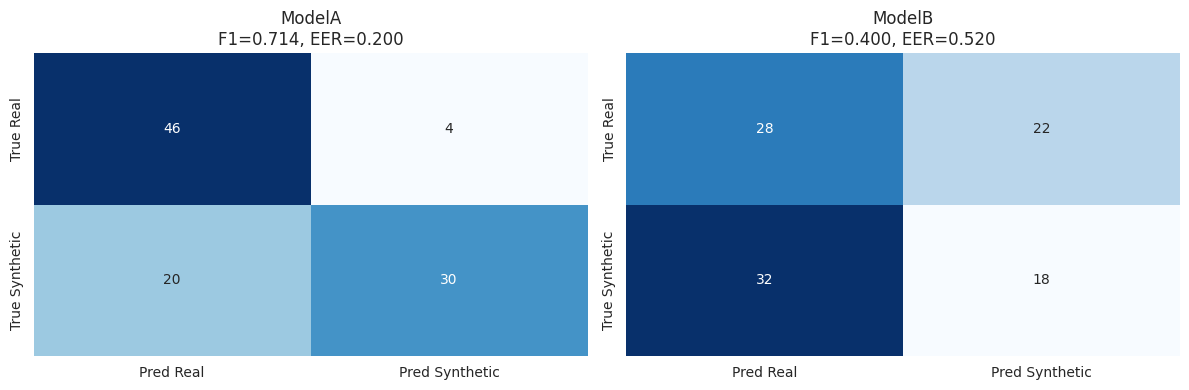

In [7]:
# Confusion matrix plots
fig, axes = plt.subplots(1, len(summary_df), figsize=(6 * len(summary_df), 4))
if len(summary_df) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, summary_df.iterrows()):
    cm = np.array([[row['tn'], row['fp']], [row['fn'], row['tp']]], dtype=int)
    annot = np.array([[f"{cm[0,0]}", f"{cm[0,1]}"], [f"{cm[1,0]}", f"{cm[1,1]}"]])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred Real', 'Pred Synthetic'],
                yticklabels=['True Real', 'True Synthetic'])
    ax.set_title(f"{row['model']}\nF1={row['f1_spoof']:.3f}, EER={row['eer']:.3f}")

plt.tight_layout()
plt.show()

In [8]:
# Save outputs
out_dir = ROOT / 'reports'
out_dir.mkdir(parents=True, exist_ok=True)

summary_path = out_dir / 'question2_part2_attack_metrics_summary.csv'
preds_path = out_dir / 'question2_part2_attack_metrics_per_file.csv'


summary_df.to_csv(summary_path, index=False)
preds_df.to_csv(preds_path, index=False)


print('Saved:')
print(summary_path)
print(preds_path)


Saved:
/DATA/Trashaimpms/ekansh/reports/question2_part2_attack_metrics_summary.csv
/DATA/Trashaimpms/ekansh/reports/question2_part2_attack_metrics_per_file.csv
